# DATA 620 Assignment 2

For this first assingment we are going to plot a simple graph of my favorite nolan movies and see how the actors relate to the movies. 
The Nodes will be 8 of Nolans movies and the actors that appear in atleast 2 of them . Even though it has nodes of two types , its still a relatively simple subset 
The Edges show which actor was in which movie. 

In [2]:
import sys
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt


## Create the graph

Each film maps to its recurring cast. Looping over that dictionary adds every node and edge.

In [3]:
films = {
    "Batman Begins":         ["Christian Bale", "Michael Caine", "Gary Oldman", "Morgan Freeman",
                              "Cillian Murphy", "Ken Watanabe"],
    "The Prestige":          ["Christian Bale", "Michael Caine"],
    "The Dark Knight":       ["Christian Bale", "Michael Caine", "Gary Oldman", "Morgan Freeman",
                              "Cillian Murphy"],
    "Inception":             ["Michael Caine", "Cillian Murphy", "Tom Hardy", "Joseph Gordon-Levitt",
                              "Marion Cotillard", "Ken Watanabe"],
    "The Dark Knight Rises": ["Christian Bale", "Michael Caine", "Gary Oldman", "Morgan Freeman",
                              "Cillian Murphy", "Tom Hardy", "Anne Hathaway",
                              "Joseph Gordon-Levitt", "Marion Cotillard"],
    "Interstellar":          ["Michael Caine", "Anne Hathaway", "Matt Damon", "Casey Affleck"],
    "Dunkirk":               ["Cillian Murphy", "Tom Hardy", "Kenneth Branagh"],
    "Tenet":                 ["Michael Caine", "Kenneth Branagh"],
    "Oppenheimer":           ["Cillian Murphy", "Gary Oldman", "Matt Damon", "Casey Affleck",
                              "Kenneth Branagh"],
}

G = nx.Graph()
for film, cast in films.items():
    for actor in cast:
        G.add_edge(film, actor)

actors = [n for n in G if n not in films]

print("Film nodes :", len(films))
print("Actor nodes:", len(actors))
print("Edges :", G.number_of_edges())

Film nodes : 9
Actor nodes: 13
Edges : 42


## Plotting

We will use network x to draw the graph. Red cirlces are films. Blue circles are actors,

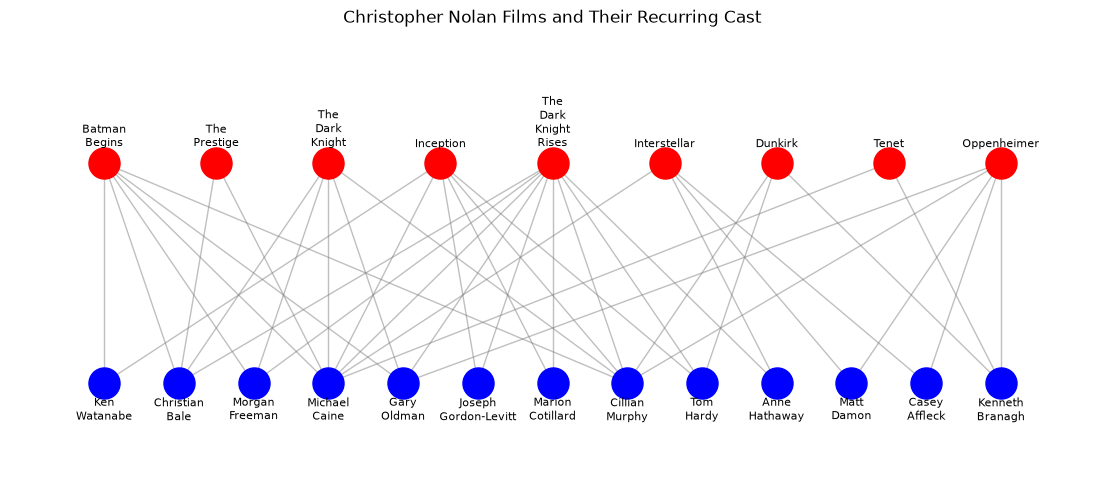

In [4]:
film_order = {f: i for i, f in enumerate(films)}
actor_order = sorted(actors, key=lambda a: sum(film_order[f] for f in G[a]) / G.degree(a))

pos = {f: (i, 1) for i, f in enumerate(films)}
pos.update({a: (i * (len(films) - 1) / (len(actors) - 1), 0) for i, a in enumerate(actor_order)})

plt.figure(figsize=(14, 6))
nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.5)
nx.draw_networkx_nodes(G, pos, nodelist=list(films), node_color="red", node_size=500)
nx.draw_networkx_nodes(G, pos, nodelist=actors, node_color="blue", node_size=500)

film_labels = {f: (pos[f][0], 1.06) for f in films}
actor_labels = {a: (pos[a][0], -0.06) for a in actors}
nx.draw_networkx_labels(G, film_labels, labels={f: f.replace(" ", "\n") for f in films},
                        font_size=8, verticalalignment="bottom")
nx.draw_networkx_labels(G, actor_labels, labels={a: a.replace(" ", "\n") for a in actors},
                        font_size=8, verticalalignment="top")

plt.title("Christopher Nolan Films and Their Recurring Cast")
plt.ylim(-0.5, 1.6)
plt.axis("off")
plt.show()

## Simple analysis : Sorting by most appearances

In [4]:
for actor in sorted(actors, key=G.degree, reverse=True)[:5]:
    print(f"{actor:<18} appears in {G.degree(actor)} films")

Michael Caine      appears in 7 films
Cillian Murphy     appears in 6 films
Christian Bale     appears in 4 films
Gary Oldman        appears in 4 films
Morgan Freeman     appears in 3 films
